## Notebook 04 - What drives price per m² in Bordeaux?
Question: how much of the price per m² is explained by surface, rooms, property type, location and year?
**Method:** load the data from PostgreSQL, explore each factor with medians, then fit a simple regression to compare their effects.

### Step 1 - Load Bordeaux data from PostgreSQL
Same connection as notebook 03. The password is typed at runtime (`getpass`), so it is never stored in the notebook or committed to Git.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

engine = create_engine(URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password=getpass("PostgreSQL password: "),
    host="localhost",
    port=5432,
    database="dvf_bordeaux",
))

bdx = pd.read_sql("SELECT * FROM sales_clean WHERE nom_commune = 'Bordeaux'", engine)
print(bdx.shape)
bdx.head()

(23419, 14)


,id_mutation,date_mutation,valeur_fonciere,code_postal,code_commune,nom_commune,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,longitude,latitude,price_per_m2,year
0,2021-502606,2021-01-05,214380.0,33000,33063,Bordeaux,Appartement,38.0,2.0,NaN,-0.570149,44.832857,5641.578947,2021
1,2021-502608,2021-01-08,153000.0,33800,33063,Bordeaux,Appartement,30.0,2.0,NaN,-0.565518,44.832603,5100.000000,2021
2,2021-502610,2021-01-04,650000.0,33000,33063,Bordeaux,Maison,120.0,3.0,171.0,-0.601241,44.829355,5416.666667,2021
3,2021-502612,2021-01-05,228000.0,33200,33063,Bordeaux,Appartement,66.0,3.0,NaN,-0.631002,44.846707,3454.545455,2021
4,2021-502613,2021-01-06,300000.0,33000,33063,Bordeaux,Maison,63.0,3.0,81.0,-0.596852,44.837450,4761.904762,2021


### Step 2 - Surface vs price per m²
Bin surface into size classes and compare medians. Small flats usually cost more per m² than large ones.

                           count       median
type_local  surface_class                    
Appartement <25             2093  5325.000000
            25-40           3446  4750.000000
            40-60           4822  4380.000000
            60-80           4118  3960.988231
            80-120          2541  4073.684211
            120+             580  4669.078014
Maison      <25               14  5770.833333
            25-40            124  6263.888889
            40-60            653  5851.063830
            60-80           1140  5183.841270
            80-120          1971  5087.719298
            120+            1917  5078.780488


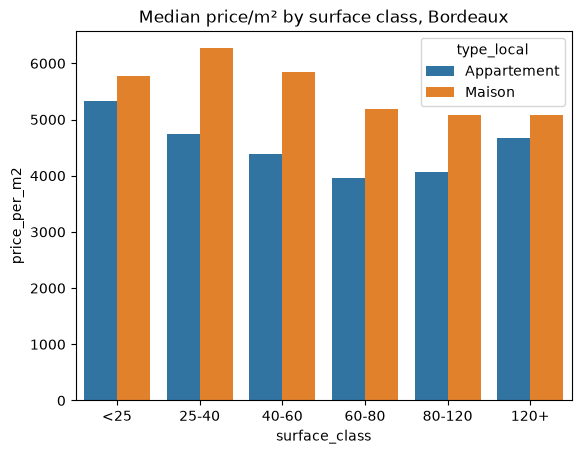

In [5]:
bdx["surface_class"] = pd.cut(bdx["surface_reelle_bati"], [0, 25, 40, 60, 80, 120, 500],
                              labels=["<25", "25-40", "40-60", "60-80", "80-120", "120+"])
t = bdx.groupby(["type_local", "surface_class"], observed=True)["price_per_m2"].agg(["count", "median"])
print(t)
sns.barplot(data=bdx, x="surface_class", y="price_per_m2", hue="type_local", estimator=np.median, errorbar=None)
plt.title("Median price/m² by surface class, Bordeaux")
plt.show()

### Step 3 - Rooms vs price per m²

In [6]:
bdx["rooms"] = bdx["nombre_pieces_principales"].clip(upper=6)
print(bdx.groupby(["type_local", "rooms"])["price_per_m2"].agg(["count", "median"]))

                   count       median
type_local  rooms                    
Appartement 0.0        7  5470.588235
            1.0     3776  4991.109422
            2.0     5857  4562.500000
            3.0     4787  4166.666667
            4.0     2343  3909.638554
            5.0      684  3569.153776
            6.0      146  4603.120879
Maison      0.0        1  7058.823529
            1.0       68  5884.210526
            2.0      502  5536.507937
            3.0     1322  5205.976190
            4.0     1698  5090.796460
            5.0     1159  5145.663265
            6.0     1069  5144.772727


In [ ]:
### Step 4 - Location: postal code
Bordeaux is split by postal code (33000, 33100, 33200, 33300, 33800), a rough proxy for neighborhoods.

In [7]:
print(bdx.groupby("code_postal")["price_per_m2"].agg(["count", "median"]).sort_values("median", ascending=False))

             count       median
code_postal                    
33000        10500  5000.000000
33800         3678  4477.272727
33100         1301  4366.197183
33200         4216  4166.666667
33300         3724  4116.963064
